In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

In [2]:
import pmdarima as pm
from prophet import Prophet
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

In [8]:
df = pd.read_csv("airline-passengers.csv",parse_dates=True,index_col=["Month"])

In [9]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [10]:
df.tail()

,Passengers
Month,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Passengers,144.0,280.298611,119.966317,104.0,180.0,265.5,360.5,622.0


In [13]:
df.index.freq = "MS"

In [17]:
df.index.month_name()

Index(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October',
       ...
       'March', 'April', 'May', 'June', 'July', 'August', 'September',
       'October', 'November', 'December'],
      dtype='object', name='Month', length=144)

In [22]:
df.columns

Index(['Passengers'], dtype='object')

In [ ]:
#EDA

In [18]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (20,5)

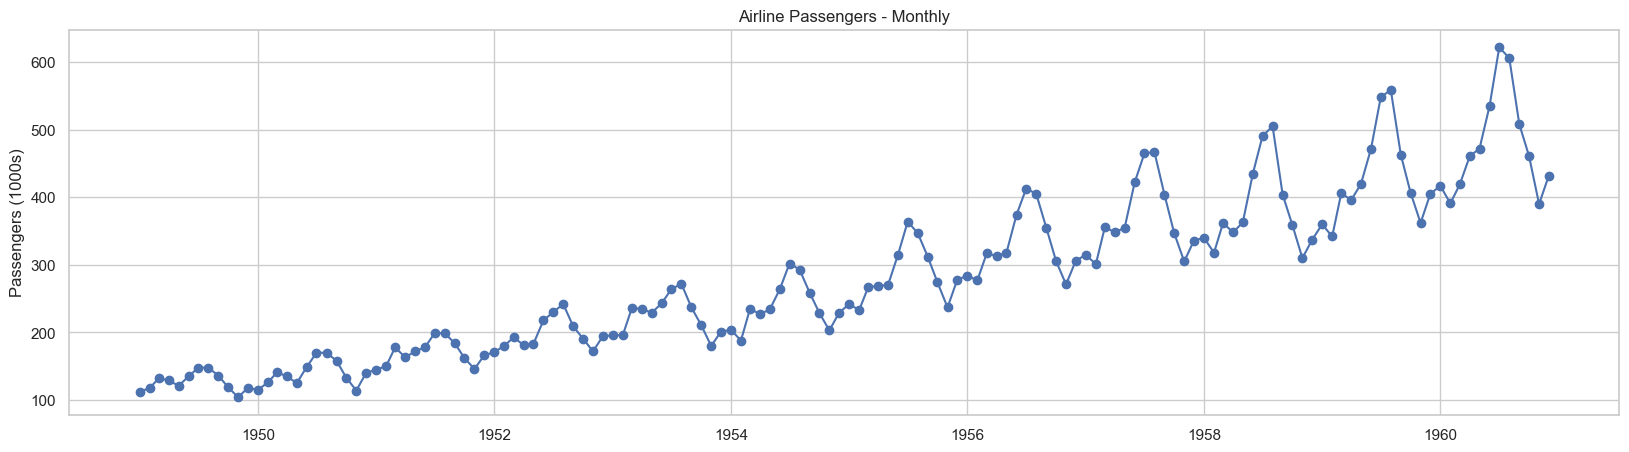

In [20]:
plt.figure()
plt.plot(df, marker='o')
plt.title('Airline Passengers - Monthly')
plt.ylabel('Passengers (1000s)')
plt.show()

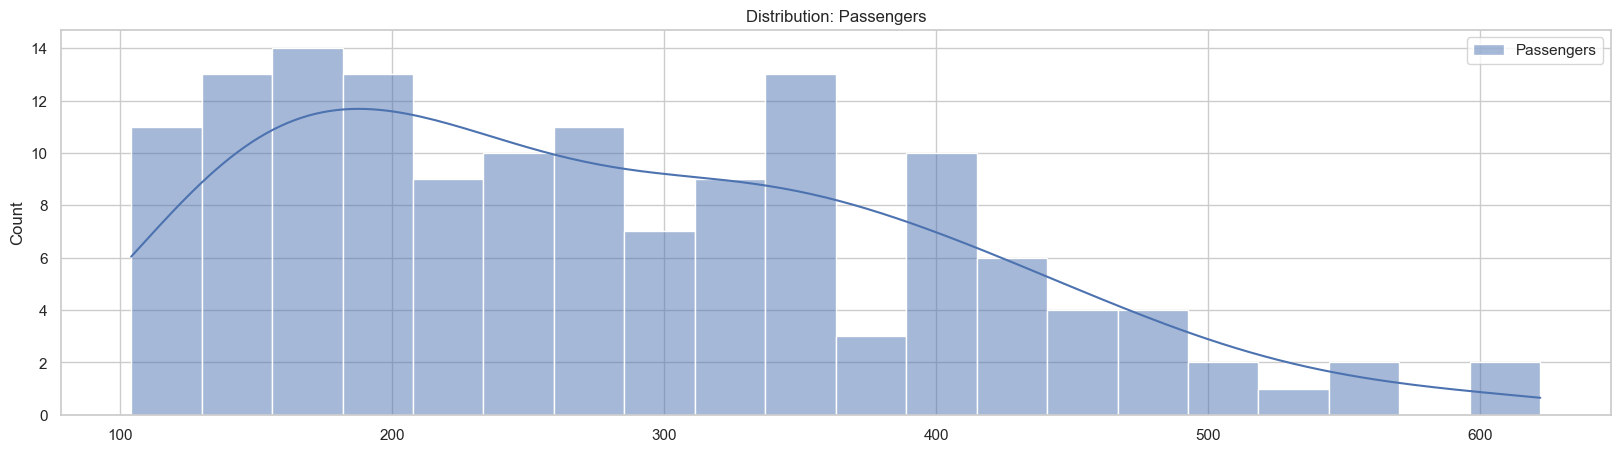

In [21]:
plt.figure()
sns.histplot(df, kde=True, bins=20)
plt.title('Distribution: Passengers')
plt.show()

<Axes: xlabel='Month', ylabel='Passengers'>

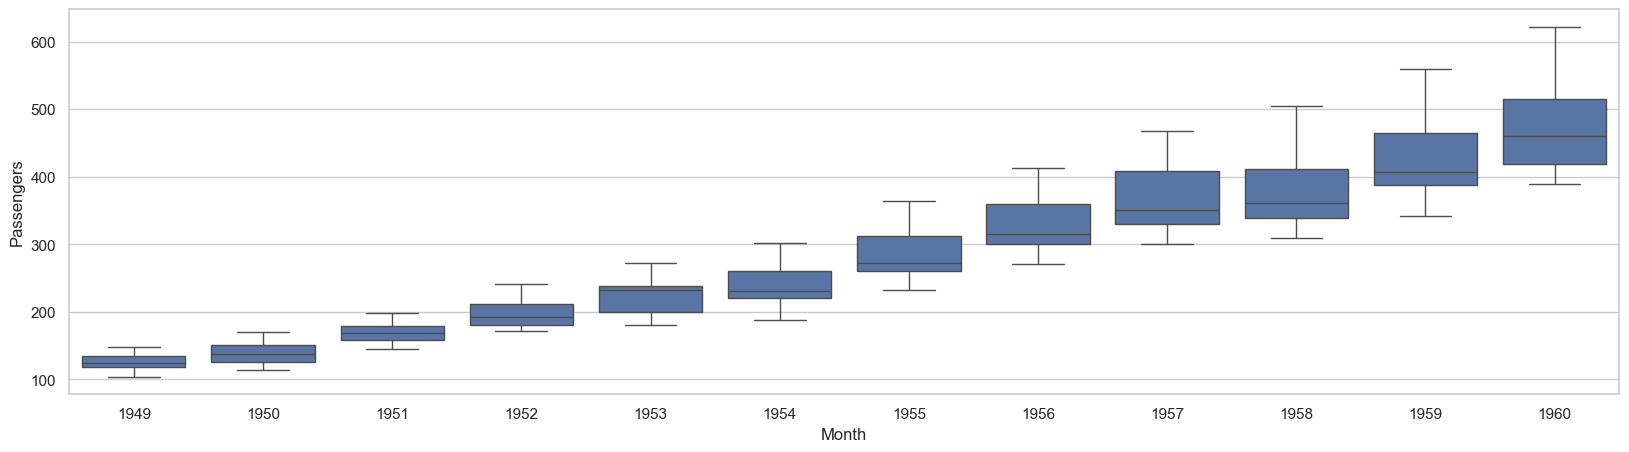

In [24]:
sns.boxplot(data=df,
            x=df.index.year,
            y="Passengers")

<Axes: xlabel='Month', ylabel='Passengers'>

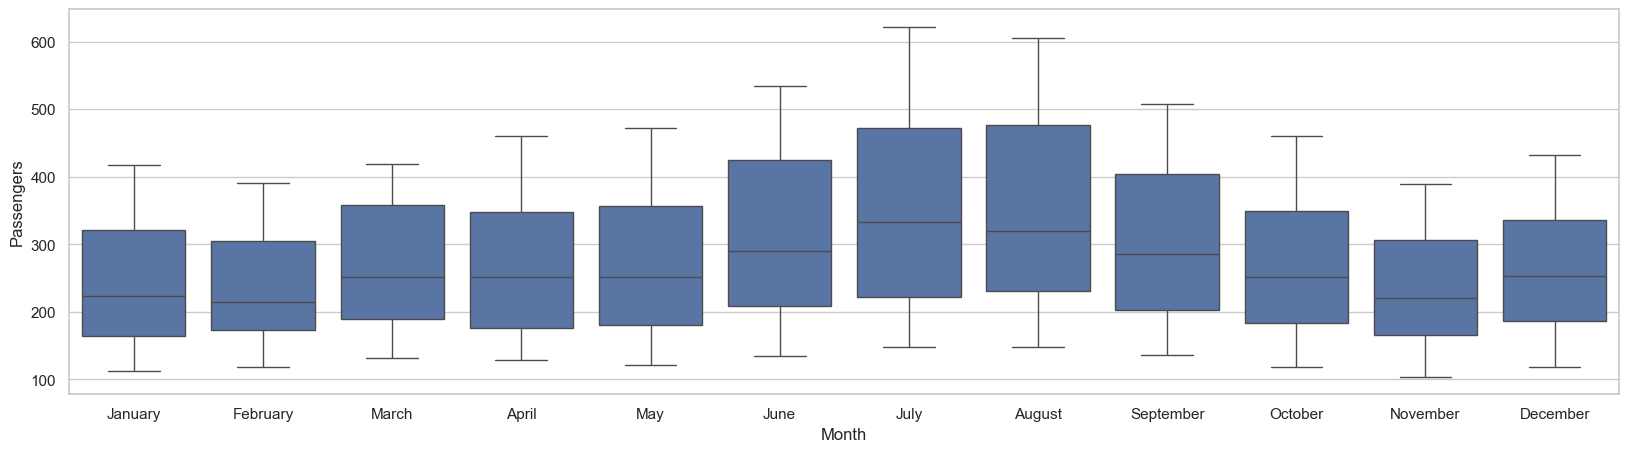

In [25]:
sns.boxplot(data=df,
            x=df.index.month_name(),
            y="Passengers")

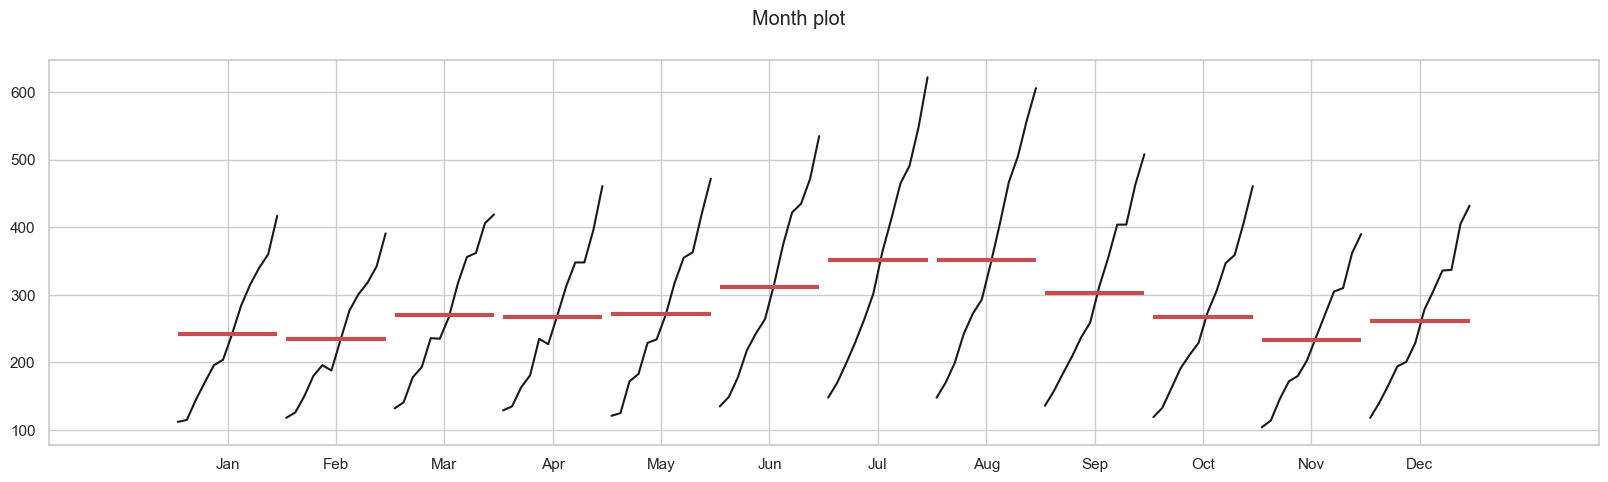

In [28]:
# 2.7 Monthplot / Quarterplot (statsmodels helper)
fig, axes = plt.subplots(1,1, figsize=(20,5))
sm.graphics.tsa.month_plot(df, ax=axes)
plt.suptitle('Month plot')
plt.show()

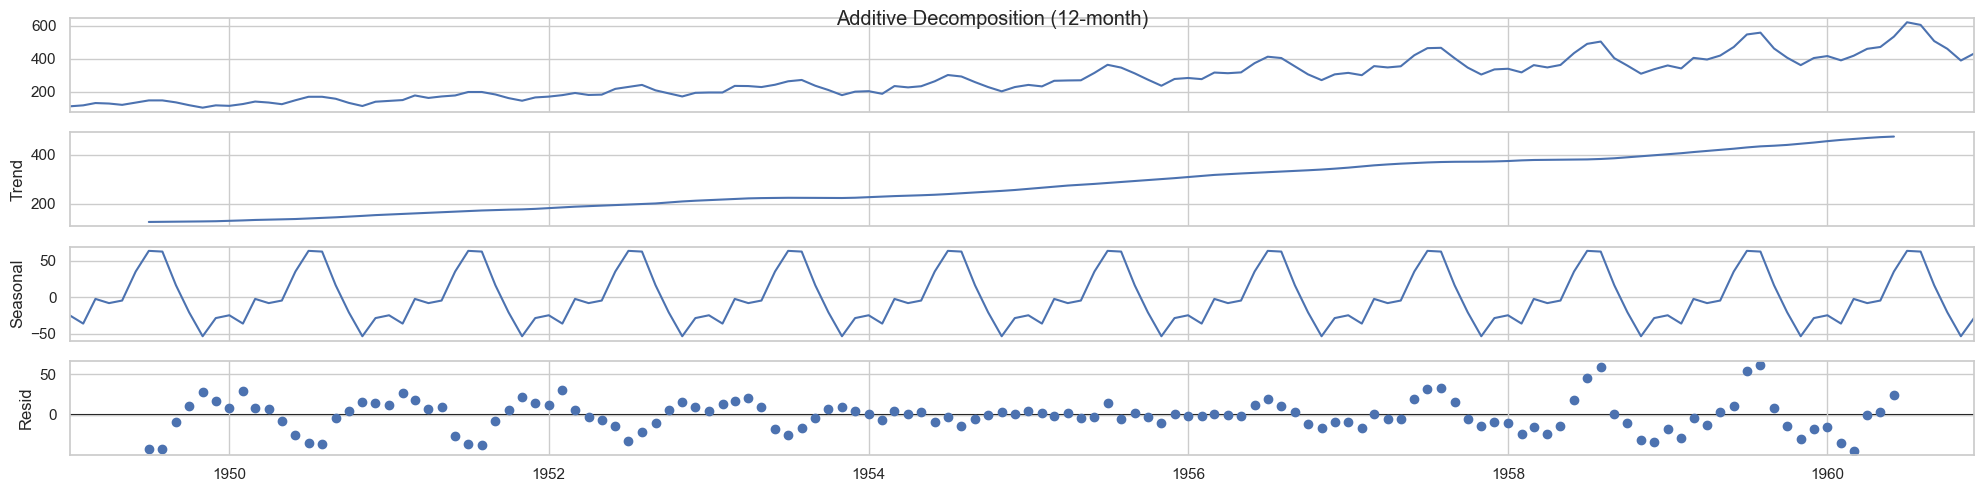

In [31]:
# Additive decomposition (for demonstration - series is multiplicative, but we'll show both)
decomp_add = seasonal_decompose(df, model='additive', period=12)
decomp_add.plot()
plt.suptitle('Additive Decomposition (12-month)')
plt.show()

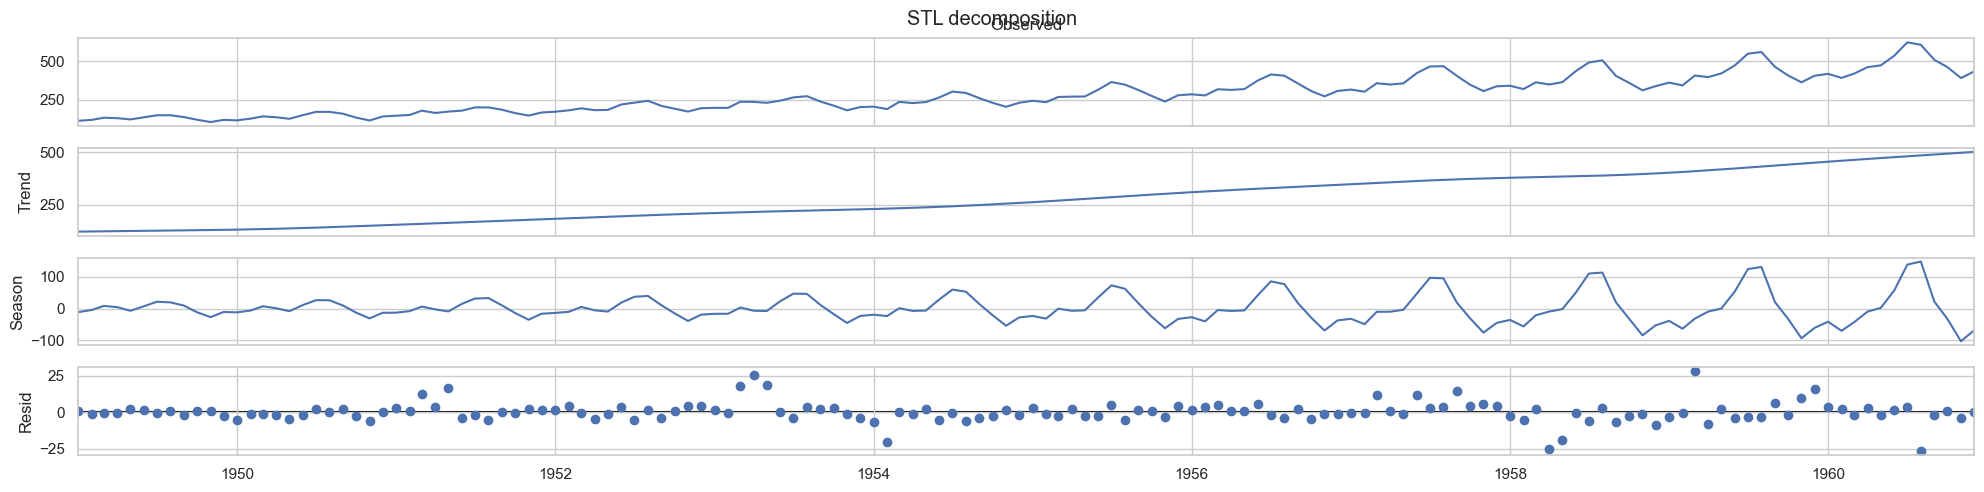

In [32]:
# STL decomposition
stl = STL(df, period=12, robust=True).fit()
stl.plot()
plt.suptitle('STL decomposition')
plt.show()

In [34]:
test_periods = 24
train = df.iloc[:-test_periods]
test  = df.iloc[-test_periods:]
print("Train:", train.index.min().date(), "to", train.index.max().date(), "n=", len(train))
print("Test:", test.index.min().date(), "to", test.index.max().date(), "n=", len(test))

Train: 1949-01-01 to 1958-12-01 n= 120
Test: 1959-01-01 to 1960-12-01 n= 24


In [35]:
hw_mul = ExponentialSmoothing(train, trend='add', seasonal='mul', seasonal_periods=12)

In [37]:
hw_mul = hw_mul.fit(optimized=True)

In [39]:
hw_mul.summary()

Dep. Variable:,Passengers,No. Observations:,120
Model:,ExponentialSmoothing,SSE,10764.241
Optimized:,True,AIC,571.579
Trend:,Additive,BIC,616.179
Seasonal:,Multiplicative,AICC,578.351
Seasonal Periods:,12,Date:,"Sat, 27 Sep 2025"
Box-Cox:,False,Time:,10:56:49
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.3642084,alpha,True
smoothing_trend,4.1912e-09,beta,True


In [40]:
hw_mul_fore = hw_mul.forecast(len(test))
print("HW (mul) RMSE:", sqrt(mean_squared_error(test, hw_mul_fore)))

HW (mul) RMSE: 32.48818087105796


<Figure size 2000x500 with 0 Axes>

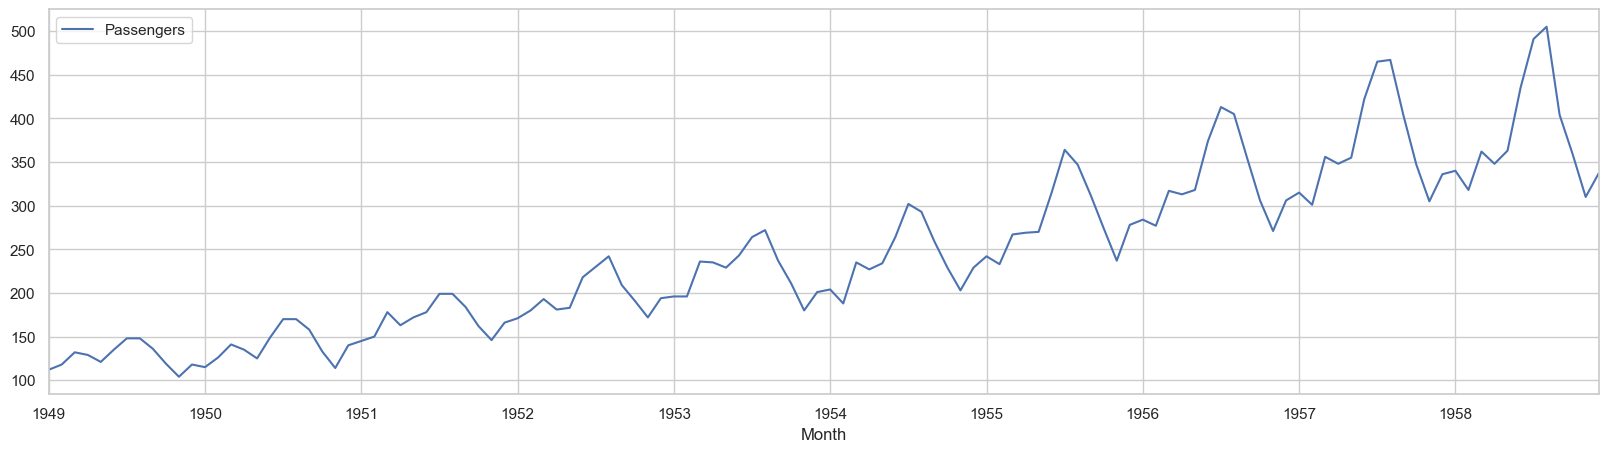

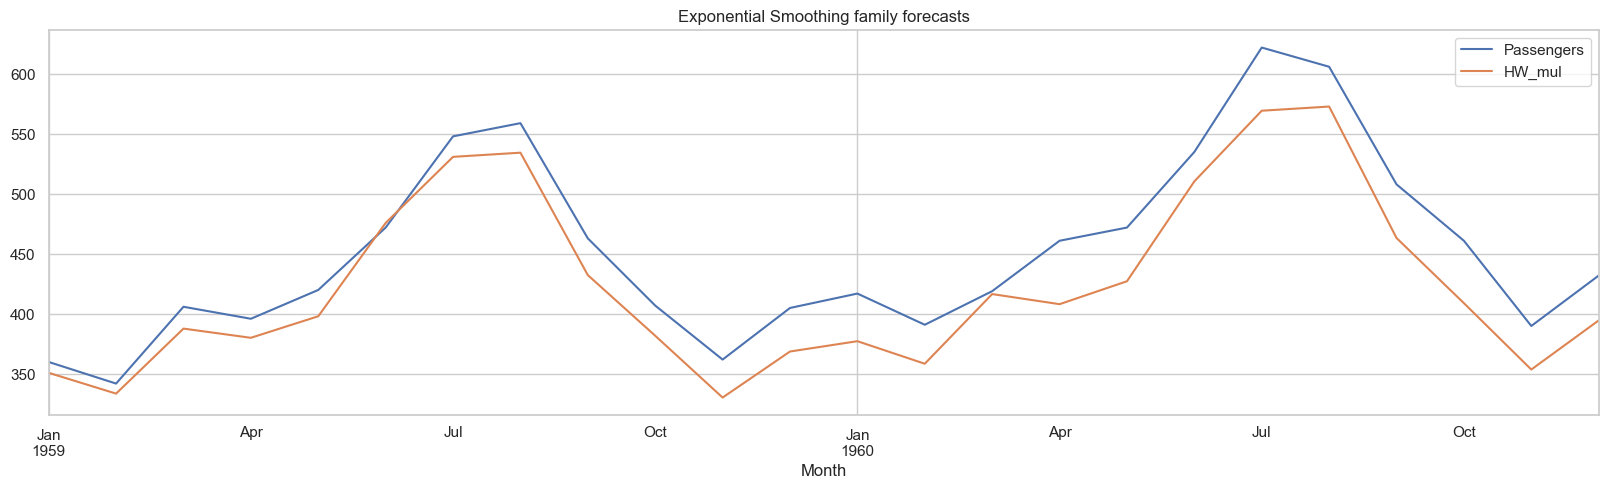

In [41]:
plt.figure()
train.plot(label='train')
test.plot(label='test')
hw_mul_fore.plot(label='HW_mul')
plt.legend()
plt.title('Exponential Smoothing family forecasts')
plt.show()

In [42]:
hw_mul = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
hw_mul = hw_mul.fit(optimized=True)

In [43]:
hw_mul.summary()

Dep. Variable:,Passengers,No. Observations:,120
Model:,ExponentialSmoothing,SSE,16033.591
Optimized:,True,AIC,619.394
Trend:,Additive,BIC,663.994
Seasonal:,Additive,AICC,626.166
Seasonal Periods:,12,Date:,"Sat, 27 Sep 2025"
Box-Cox:,False,Time:,11:03:51
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.2367868,alpha,True
smoothing_trend,1.8056e-09,beta,True


In [44]:
hw_mul_fore = hw_mul.forecast(len(test))
print("HW (mul) RMSE:", sqrt(mean_squared_error(test, hw_mul_fore)))

HW (mul) RMSE: 35.757539410127215


<Figure size 2000x500 with 0 Axes>

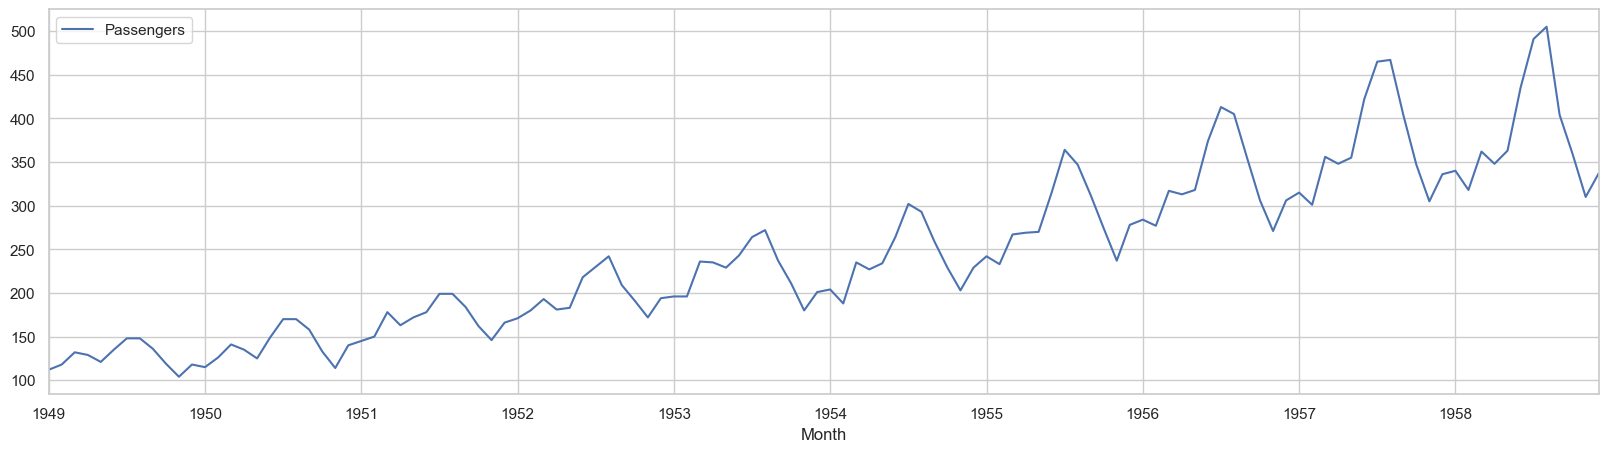

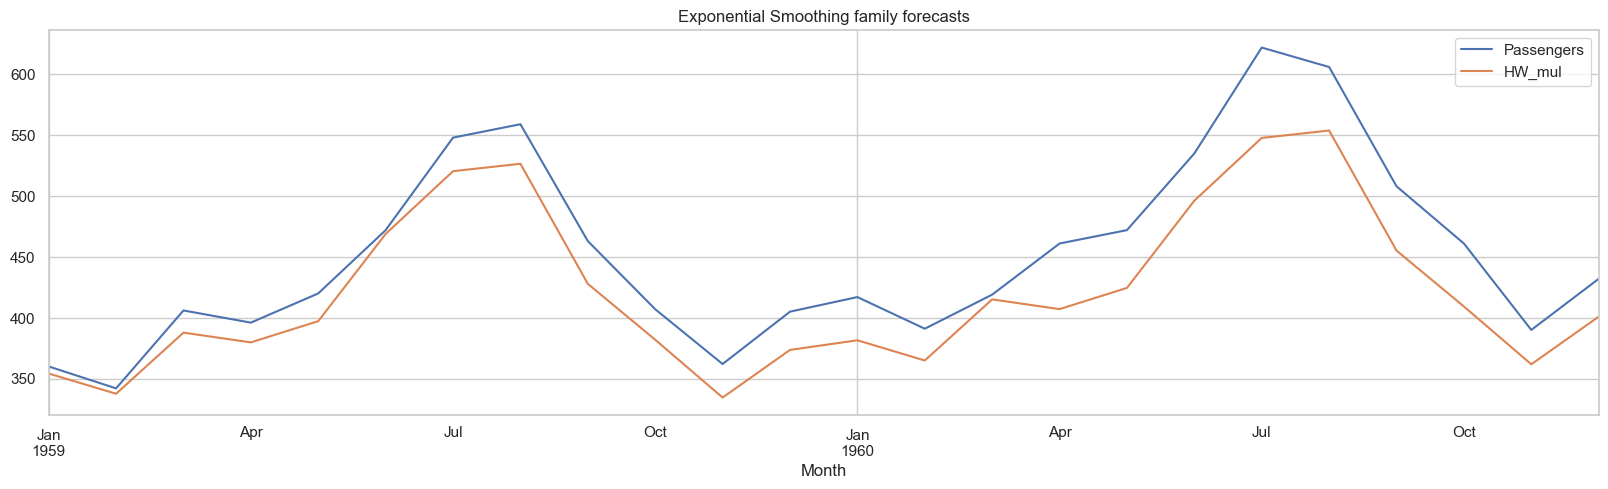

In [45]:
plt.figure()
train.plot(label='train')
test.plot(label='test')
hw_mul_fore.plot(label='HW_mul')
plt.legend()
plt.title('Exponential Smoothing family forecasts')
plt.show()

In [46]:
alphas = [0.2, 0.4, 0.6]
betas = [0.05, 0.2,0.4]
gammas = [0.05, 0.2,0.4,0.6,0.8]
trends = ['add']
seasonals = ['add', 'mul']

hw_results = []
best_hw = None
best_rmse = np.inf

for trend in trends:
    for seasonal in seasonals:
        for a in alphas:
            for b in betas:
                for g in gammas:
                    try:
                        model = ExponentialSmoothing(train, trend=trend, seasonal=seasonal, seasonal_periods=12)
                        fit = model.fit(smoothing_level=a, smoothing_slope=b, smoothing_seasonal=g, optimized=False)
                        pred = fit.forecast(len(test))
                        rmse = sqrt(mean_squared_error(test, pred))
                        hw_results.append({'trend':trend, 'seasonal':seasonal, 'alpha':a, 'beta':b, 'gamma':g, 'rmse':rmse})
                        if rmse < best_rmse:
                            best_rmse = rmse
                            best_hw = {'fit':fit, 'config':(trend, seasonal, a, b, g), 'rmse':rmse}
                    except Exception as e:
                        continue

In [48]:
hw_df

,trend,seasonal,alpha,beta,gamma,rmse
0,add,add,0.4,0.2,0.60,14.342691
1,add,add,0.2,0.4,0.60,15.042238
2,add,add,0.2,0.4,0.40,15.711134
3,add,mul,0.2,0.4,0.20,18.988837
4,add,mul,0.4,0.2,0.40,20.730030
...,...,...,...,...,...,...
85,add,add,0.4,0.4,0.05,305.561179
86,add,add,0.6,0.4,0.40,333.227858
87,add,mul,0.6,0.4,0.80,339.297693
88,add,add,0.6,0.4,0.05,419.700330


In [47]:
hw_df = pd.DataFrame(hw_results).sort_values('rmse').reset_index(drop=True)
print("Top 6 Holt-Winters configs by RMSE:")
display(hw_df.head(6))
print("Best HW RMSE:", best_hw['rmse'], "config:", best_hw['config'])

Top 6 Holt-Winters configs by RMSE:


,trend,seasonal,alpha,beta,gamma,rmse
0,add,add,0.4,0.2,0.6,14.342691
1,add,add,0.2,0.4,0.6,15.042238
2,add,add,0.2,0.4,0.4,15.711134
3,add,mul,0.2,0.4,0.2,18.988837
4,add,mul,0.4,0.2,0.4,20.730030
5,add,mul,0.2,0.4,0.6,22.255340


Best HW RMSE: 14.342690820651246 config: ('add', 'add', 0.4, 0.2, 0.6)


In [49]:
hw_best = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
hw_best = hw_best.fit(smoothing_level=0.4, smoothing_slope=0.2, smoothing_seasonal=0.6, optimized=False)

<Figure size 2000x500 with 0 Axes>

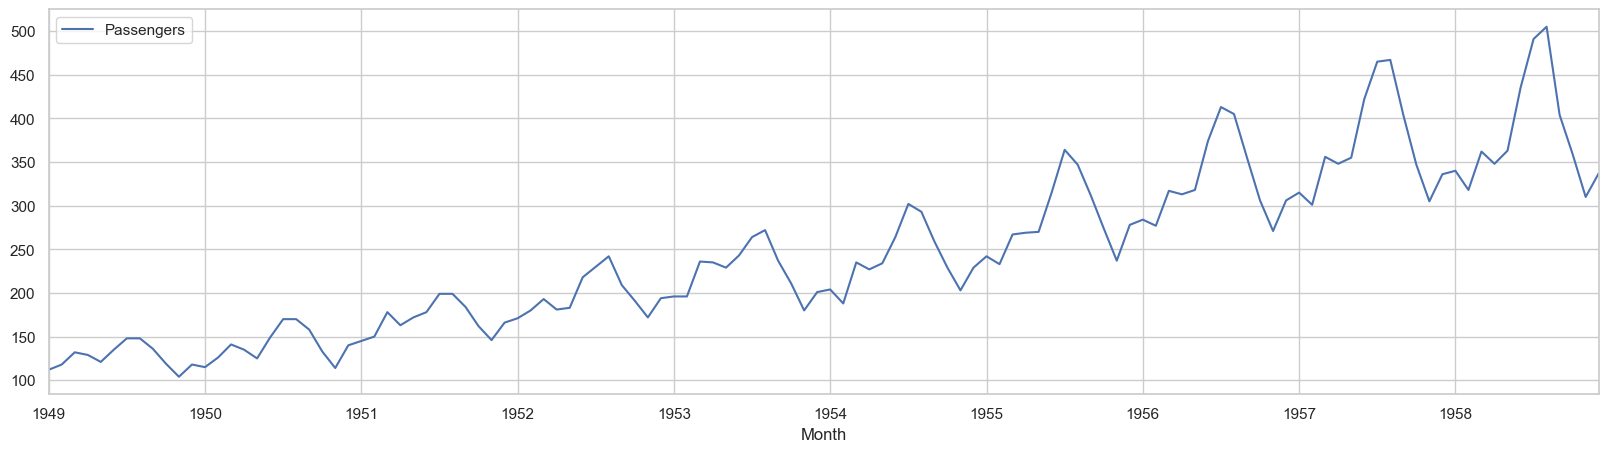

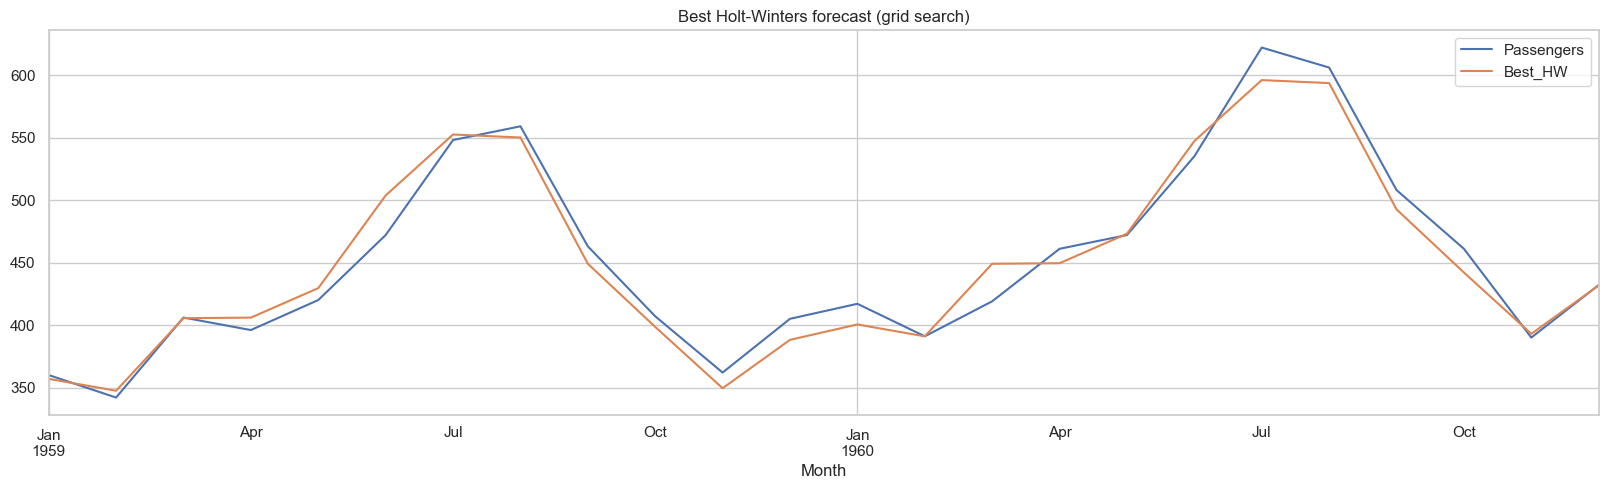

In [50]:
# plot best hw
best_hw_fore = hw_best.forecast(len(test))
plt.figure()
train.plot(label='train')
test.plot(label='test')
best_hw_fore.plot(label='Best_HW')
plt.legend(); plt.title('Best Holt-Winters forecast (grid search)')
plt.show()

In [52]:
hw_final = ExponentialSmoothing(df, trend='add', seasonal='add', seasonal_periods=12)
hw_final = hw_final.fit(smoothing_level=0.4, smoothing_slope=0.2, smoothing_seasonal=0.6, optimized=False)

<Figure size 2000x500 with 0 Axes>

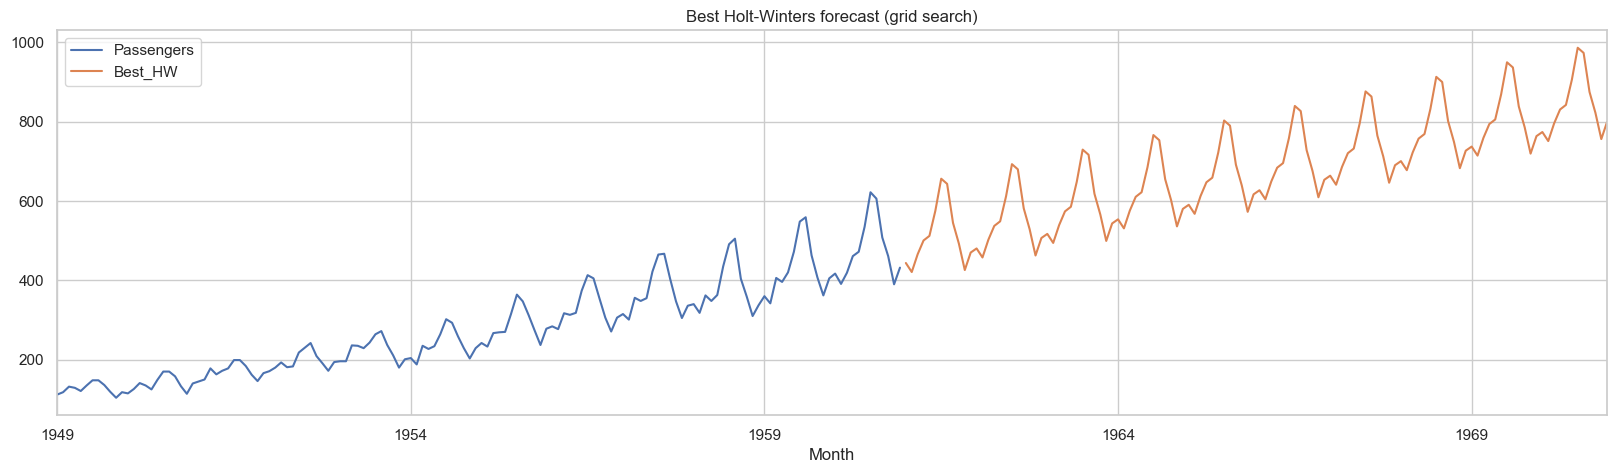

In [56]:
# plot best hw
best_hw_fore = hw_final.forecast(120)
plt.figure()
df.plot(label='train')
best_hw_fore.plot(label='Best_HW')
plt.legend(); plt.title('Best Holt-Winters forecast (grid search)')
plt.show()

In [ ]:
#SARIMA 

p,d,q
P,D,Q,m 

m = 12 

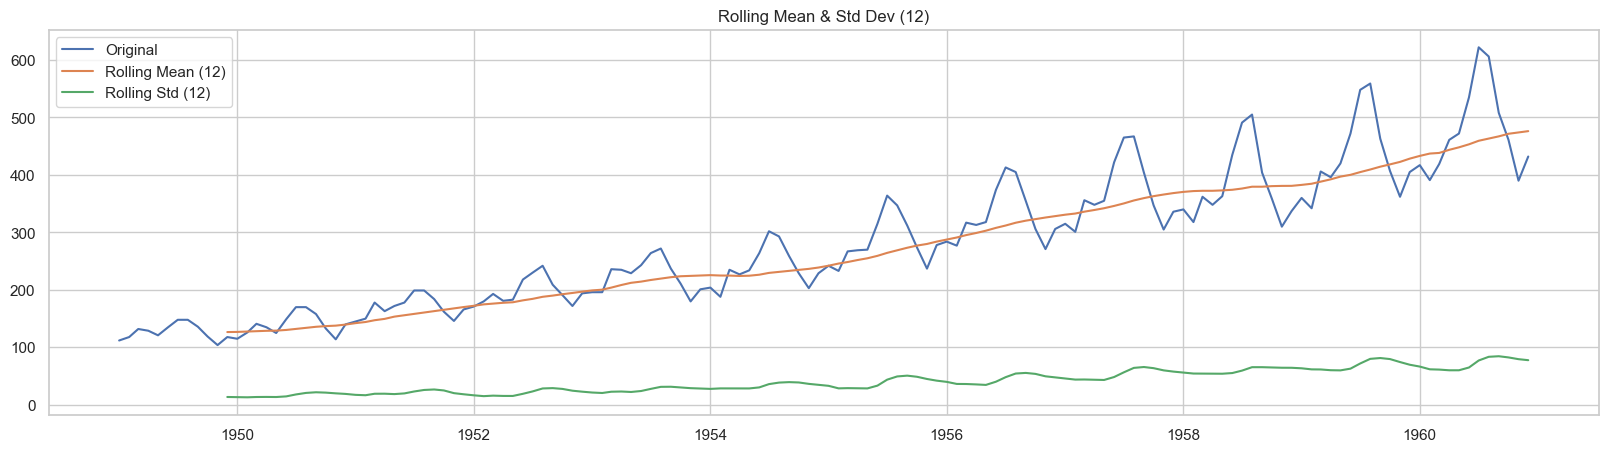

In [58]:
rolling_mean = df.rolling(12).mean()
rolling_std  = df.rolling(12).std()
plt.figure()
plt.plot(df, label='Original')
plt.plot(rolling_mean, label='Rolling Mean (12)')
plt.plot(rolling_std, label='Rolling Std (12)')
plt.legend()
plt.title('Rolling Mean & Std Dev (12)')
plt.show()

In [59]:
def adf_print(x, name="series"):
    res = adfuller(x.dropna())
    print(f"ADF for {name}: statistic={res[0]:.4f}, p-value={res[1]:.4f}")
    for k, v in res[4].items():
        print(f"  critical value {k}: {v:.4f}")
    print()

In [60]:
adf_print(df, "Raw series")

ADF for Raw series: statistic=0.8154, p-value=0.9919
  critical value 1%: -3.4817
  critical value 5%: -2.8840
  critical value 10%: -2.5788



In [ ]:
H0 : Series is non stationary
HA : Series is sationary

pv > 0.05 , Failing to Reject , Series is non stationary

In [61]:
adf_print(df.diff().dropna(), "Raw series")

ADF for Raw series: statistic=-2.8293, p-value=0.0542
  critical value 1%: -3.4817
  critical value 5%: -2.8840
  critical value 10%: -2.5788



In [62]:
adf_print(df.diff(12).dropna(), "Raw series")

ADF for Raw series: statistic=-3.3830, p-value=0.0116
  critical value 1%: -3.4817
  critical value 5%: -2.8840
  critical value 10%: -2.5788



In [65]:
df_s_Diff = df.diff(12).dropna()
df_s_Diff

,Passengers
Month,
1950-01-01,3.0
1950-02-01,8.0
1950-03-01,9.0
1950-04-01,6.0
1950-05-01,4.0
...,...
1960-08-01,47.0
1960-09-01,45.0
1960-10-01,54.0


In [66]:
df_s_Diff.diff()

,Passengers
Month,
1950-01-01,NaN
1950-02-01,5.0
1950-03-01,1.0
1950-04-01,-3.0
1950-05-01,-2.0
...,...
1960-08-01,-27.0
1960-09-01,-2.0
1960-10-01,9.0


In [64]:
adf_print(df.diff(12).dropna().diff().dropna(), "Raw series")

ADF for Raw series: statistic=-15.5956, p-value=0.0000
  critical value 1%: -3.4817
  critical value 5%: -2.8840
  critical value 10%: -2.5788



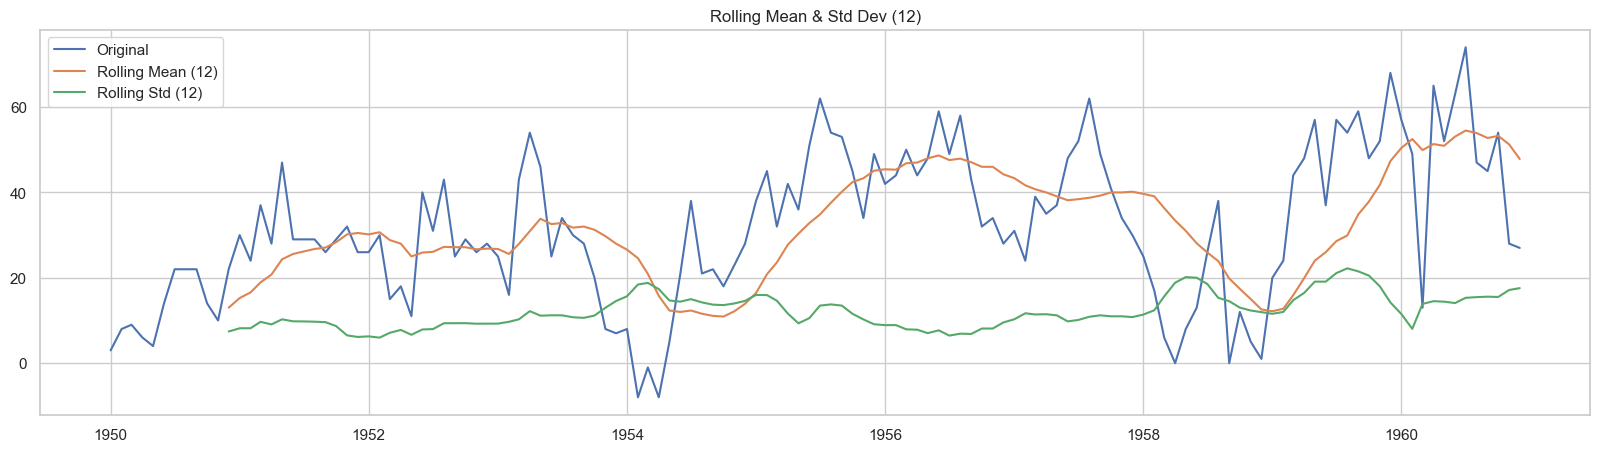

In [68]:
rolling_mean = df.diff(12).dropna().rolling(12).mean()
rolling_std  = df.diff(12).dropna().rolling(12).std()
plt.figure()
plt.plot(df.diff(12).dropna(), label='Original')
plt.plot(rolling_mean, label='Rolling Mean (12)')
plt.plot(rolling_std, label='Rolling Std (12)')
plt.legend()
plt.title('Rolling Mean & Std Dev (12)')
plt.show()

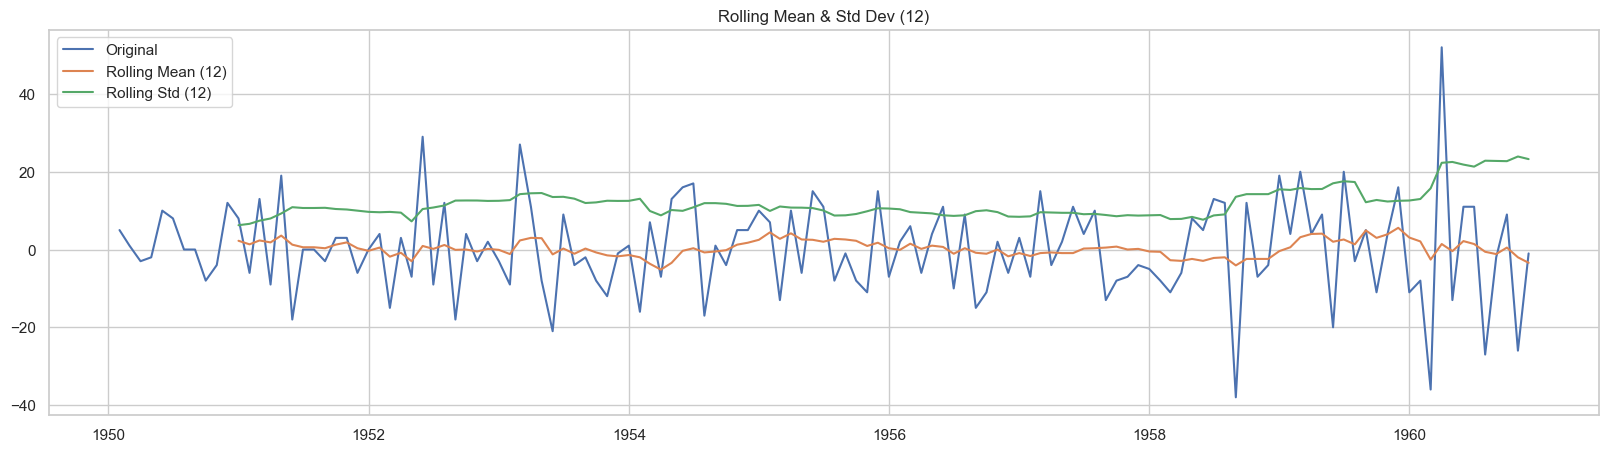

In [67]:
rolling_mean = df.diff(12).dropna().diff().dropna().rolling(12).mean()
rolling_std  = df.diff(12).dropna().diff().dropna().rolling(12).std()
plt.figure()
plt.plot(df.diff(12).dropna().diff().dropna(), label='Original')
plt.plot(rolling_mean, label='Rolling Mean (12)')
plt.plot(rolling_std, label='Rolling Std (12)')
plt.legend()
plt.title('Rolling Mean & Std Dev (12)')
plt.show()

In [ ]:
d = 1
D = 1

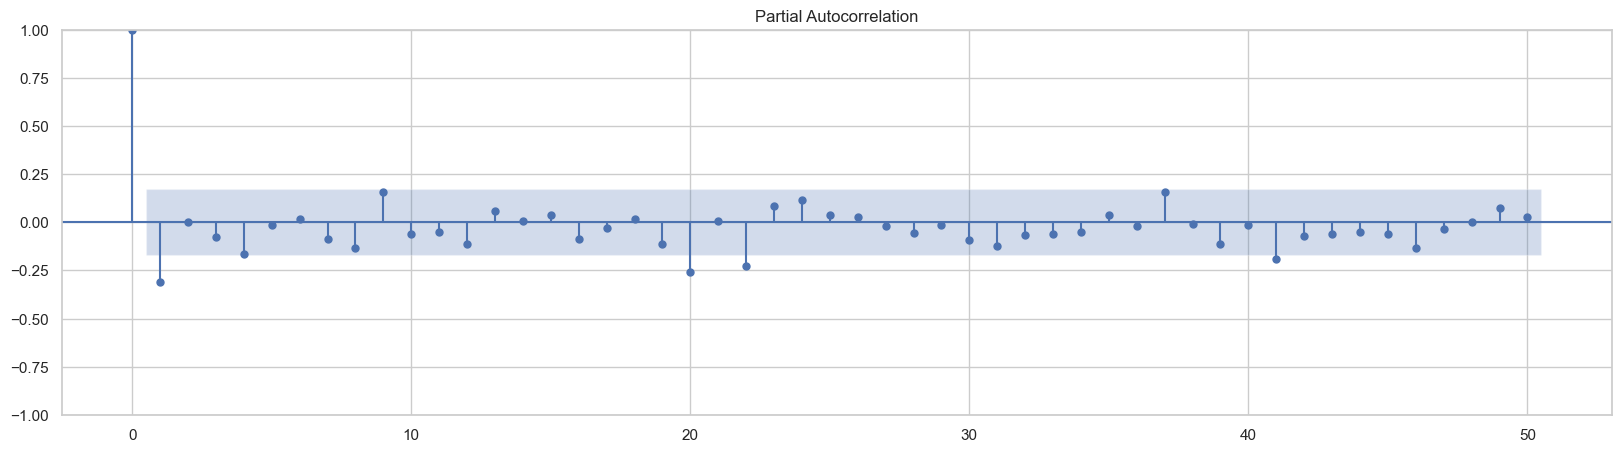

In [70]:
plot_pacf(df.diff(12).dropna().diff().dropna(),lags=50);

In [ ]:
p = 1
P = 0

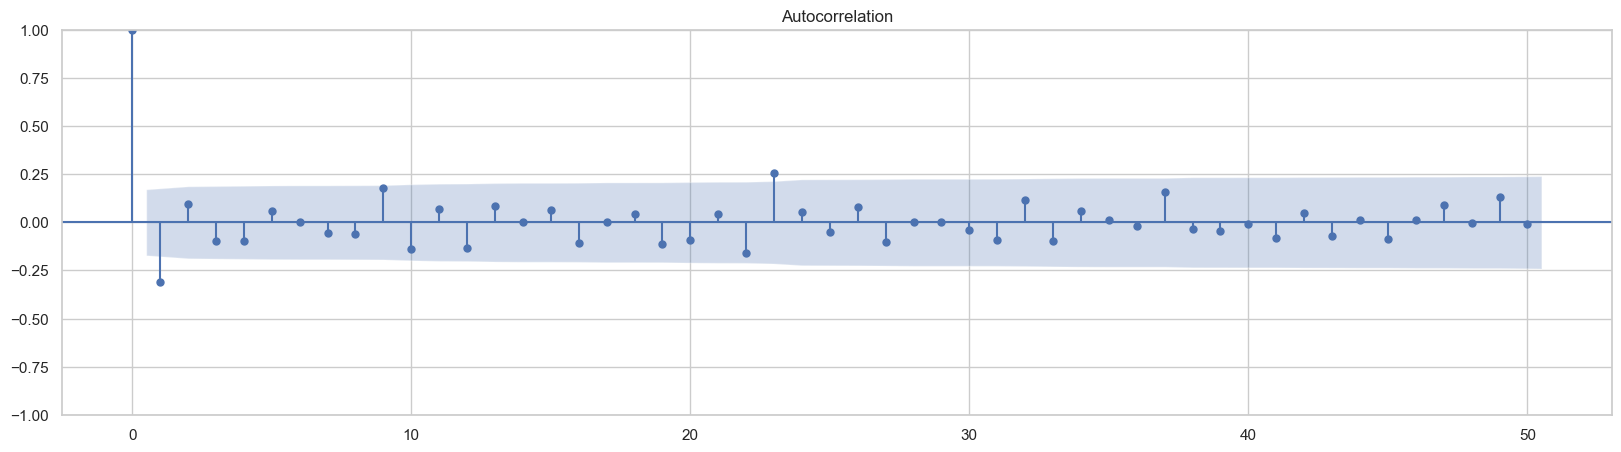

In [71]:
plot_acf(df.diff(12).dropna().diff().dropna(),lags=50);

In [ ]:
q = 1
Q = 0

(1,1,1)(0,1,0,12)

In [72]:
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(0,1,0,12),
                          enforce_stationarity=False, enforce_invertibility=False)

In [73]:
s_model = sarima_model.fit()

In [74]:
s_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                          Passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(0, 1, [], 12)   Log Likelihood                -392.762
Date:                             Sat, 27 Sep 2025   AIC                            791.524
Time:                                     12:16:46   BIC                            799.486
Sample:                                 01-01-1949   HQIC                           794.750
                                      - 12-01-1958                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5209      0.361     -1.444      0.149      -1.228       0.186
ma.L1          0.2998      0.383      0.783      0.434      -0.451       1.050
sigma2       103.8861     12.541      8.284      0.000      79.306     128.466
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.46
Prob(Q):                              0.97   Prob(JB):                         0.29
Heteroskedasticity (H):               1.44   Skew:                            -0.02
Prob(H) (two-sided):                  0.28   Kurtosis:                         3.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [77]:
forecast_data = s_model.forecast(steps=len(test))

<Figure size 2000x500 with 0 Axes>

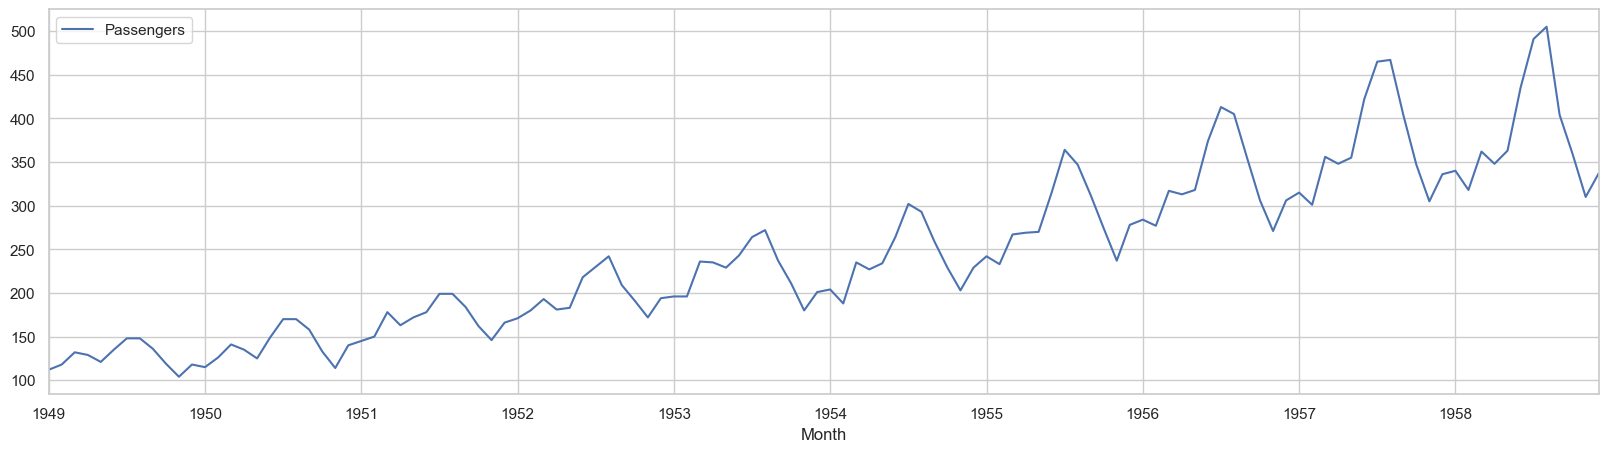

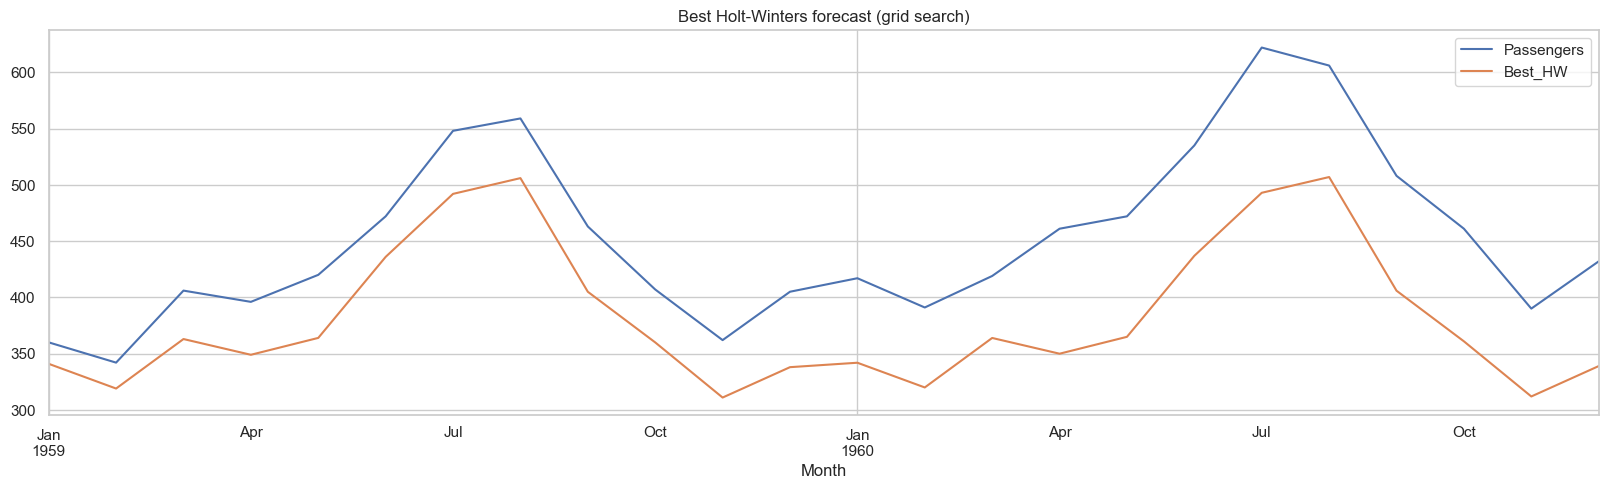

In [78]:
plt.figure()
train.plot(label='train')
test.plot(label='test')
forecast_data.plot(label='Best_HW')
plt.legend(); plt.title('Best Holt-Winters forecast (grid search)')
plt.show()

In [79]:
auto = pm.auto_arima(train, 
                     seasonal=True,
                     m=12, 
                     stepwise=True, 
                     suppress_warnings=True, 
                     trace=True, 
                     error_action='ignore',
                    d=1,
                    D=1,
                    start_p=1,
                    start_q=1,
                    max_p=5,
                    max_q=5,
                    start_P=0,
                    start_Q=0,
                    max_P=3,
                    max_Q=3)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=804.813, Time=0.08 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=807.655, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=804.973, Time=0.07 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=805.408, Time=0.11 sec
 ARIMA(1,1,1)(1,1,0)[12]             : AIC=806.500, Time=0.13 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=806.570, Time=0.18 sec
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=807.660, Time=0.40 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=803.650, Time=0.05 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=805.339, Time=0.09 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=inf, Time=0.56 sec
 ARIMA(0,1,2)(0,1,0)[12]             : AIC=805.629, Time=0.08 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=803.281, Time=0.04 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=805.044, Time=0.10 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=0.43 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AI

In [84]:
import itertools
p = q = range(0,5)
d = [1]
pdq = list(itertools.product(p, d, q))
P = Q = range(0,5)
D=[1]
m = [12]
PDQm = list(itertools.product(P,D,Q,m))

In [86]:
PDQm

[(0, 1, 0, 12),
 (0, 1, 1, 12),
 (0, 1, 2, 12),
 (0, 1, 3, 12),
 (0, 1, 4, 12),
 (1, 1, 0, 12),
 (1, 1, 1, 12),
 (1, 1, 2, 12),
 (1, 1, 3, 12),
 (1, 1, 4, 12),
 (2, 1, 0, 12),
 (2, 1, 1, 12),
 (2, 1, 2, 12),
 (2, 1, 3, 12),
 (2, 1, 4, 12),
 (3, 1, 0, 12),
 (3, 1, 1, 12),
 (3, 1, 2, 12),
 (3, 1, 3, 12),
 (3, 1, 4, 12),
 (4, 1, 0, 12),
 (4, 1, 1, 12),
 (4, 1, 2, 12),
 (4, 1, 3, 12),
 (4, 1, 4, 12)]

In [87]:
best_aic = np.inf
best_order = None
best_seasonal = None
best_sarima_res = None
sarima_results = []

for order in pdq:
    for seasonal in PDQm:
        try:
            mod = SARIMAX(train, order=order, seasonal_order=seasonal,
                          enforce_stationarity=False, enforce_invertibility=False)
            res = mod.fit(disp=False, maxiter=50)
            aic = res.aic
            pred = res.get_forecast(steps=len(test)).predicted_mean
            rmse = sqrt(mean_squared_error(test, pred))
            sarima_results.append({'order':order, 'seasonal':seasonal, 'aic':aic, 'rmse':rmse})
            if aic < best_aic:
                best_aic = aic
                best_order = order
                best_seasonal = seasonal
                best_sarima_res = res
        except Exception as e:
            continue

C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Conver

In [ ]:
sarima_df = pd.DataFrame(sarima_results).sort_values('aic').reset_index(drop=True)
print("Top SARIMA candidates by AIC:")
display(sarima_df.head(6))
print("Best SARIMA order:", best_order, "seasonal:", best_seasonal, "AIC:", best_aic)

# Forecast & evaluate best SARIMA
if best_sarima_res is not None:
    pred_log = best_sarima_res.get_forecast(steps=len(test_log)).predicted_mean
    sarima_fore = np.exp(pred_log)
    print("Best SARIMA RMSE:", sqrt(mean_squared_error(test, sarima_fore)))
    plt.figure()
    train.plot(label='train')
    test.plot(label='test')
    sarima_fore.plot(label='SARIMA_best')
    plt.legend(); plt.title('Best SARIMA forecast')
    plt.show()
    # Diagnostics
    best_sarima_res.plot_diagnostics(figsize=(12,8))
    plt.show()

In [89]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [90]:
prophet_df = df.reset_index().rename(columns={'Month':'ds','Passengers':'y'})

In [91]:
prophet_df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [100]:
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,seasonality_mode="multiplicative")

In [101]:
prophet_train_df = prophet_df.iloc[:-test_periods]
m.fit(prophet_train_df)

12:39:20 - cmdstanpy - INFO - Chain [1] start processing
12:39:20 - cmdstanpy - INFO - Chain [1] done processing


In [102]:
future = m.make_future_dataframe(periods=24, freq='MS')
forecast = m.predict(future)

In [97]:
forecast.tail(5)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
139,1960-08-01,466.108129,496.333814,545.555142,464.804055,467.370844,55.679362,55.679362,55.679362,55.679362,55.679362,55.679362,0.0,0.0,0.0,521.787491
140,1960-09-01,469.090843,459.048215,505.722311,467.687612,470.491843,13.047557,13.047557,13.047557,13.047557,13.047557,13.047557,0.0,0.0,0.0,482.138399
141,1960-10-01,471.977340,425.454744,473.820857,470.433807,473.496433,-22.167996,-22.167996,-22.167996,-22.167996,-22.167996,-22.167996,0.0,0.0,0.0,449.809344
142,1960-11-01,474.960054,397.158160,445.030767,473.322800,476.581413,-53.344612,-53.344612,-53.344612,-53.344612,-53.344612,-53.344612,0.0,0.0,0.0,421.615443
143,1960-12-01,477.846552,425.222265,471.962627,476.113737,479.589169,-29.966927,-29.966927,-29.966927,-29.966927,-29.966927,-29.966927,0.0,0.0,0.0,447.879625


In [103]:
forecast.tail(5)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yearly,yearly_lower,yearly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
139,1960-08-01,451.515094,541.004537,567.176877,446.839009,456.189714,0.227429,0.227429,0.227429,0.227429,0.227429,0.227429,0.0,0.0,0.0,554.202836
140,1960-09-01,453.942667,464.609795,489.238610,448.826469,458.943787,0.051451,0.051451,0.051451,0.051451,0.051451,0.051451,0.0,0.0,0.0,477.298499
141,1960-10-01,456.291932,403.082543,428.772491,450.932225,461.666008,-0.088804,-0.088804,-0.088804,-0.088804,-0.088804,-0.088804,0.0,0.0,0.0,415.771321
142,1960-11-01,458.719505,353.271705,379.806077,453.055580,464.474085,-0.200175,-0.200175,-0.200175,-0.200175,-0.200175,-0.200175,0.0,0.0,0.0,366.895142
143,1960-12-01,461.068769,393.968074,420.801163,454.954341,467.276430,-0.115750,-0.115750,-0.115750,-0.115750,-0.115750,-0.115750,0.0,0.0,0.0,407.699859


In [104]:
# fit on train only
prop_pred = forecast.set_index('ds')['yhat'][-test_periods:]
prop_pred.index = test.index  # align index
print("Prophet RMSE:", sqrt(mean_squared_error(test, prop_pred)))

Prophet RMSE: 29.648100248201924


<Figure size 2000x500 with 0 Axes>

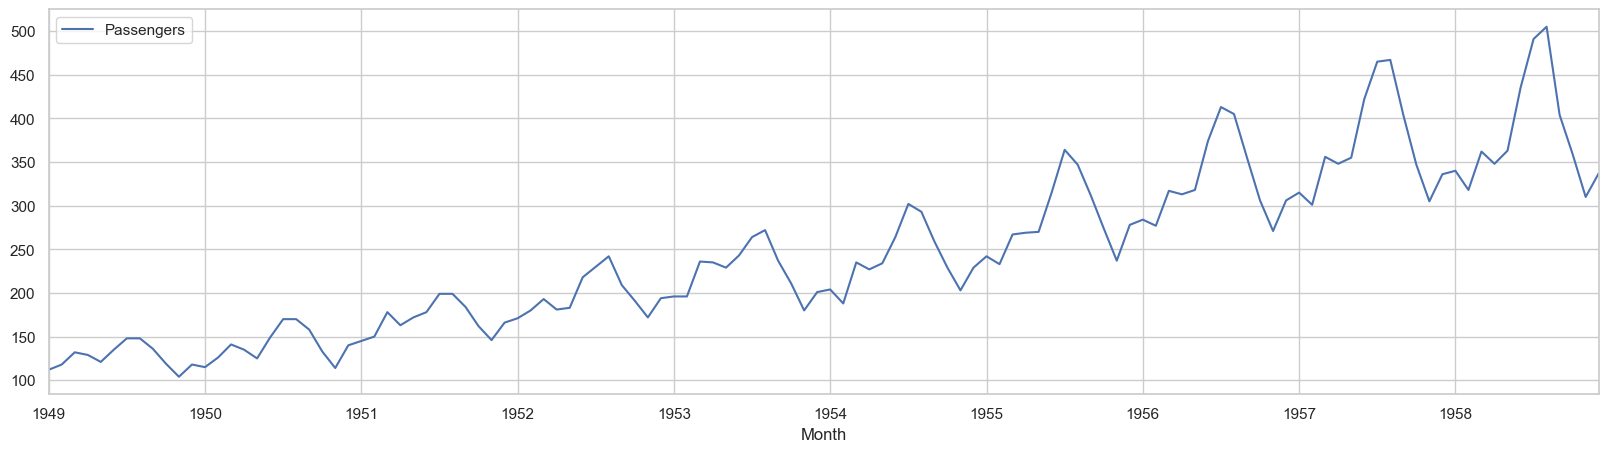

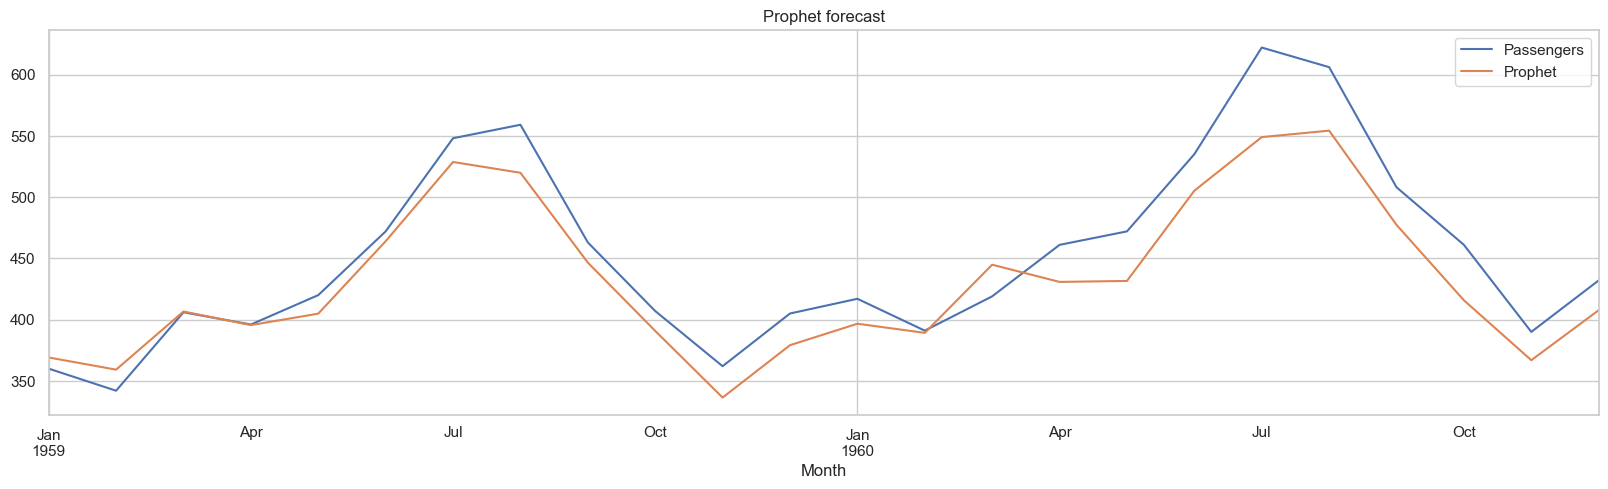

In [105]:
# Plot
plt.figure()
train.plot(label='train'); 
test.plot(label='test'); 
prop_pred.plot(label='Prophet')
plt.legend(); plt.title('Prophet forecast')
plt.show()

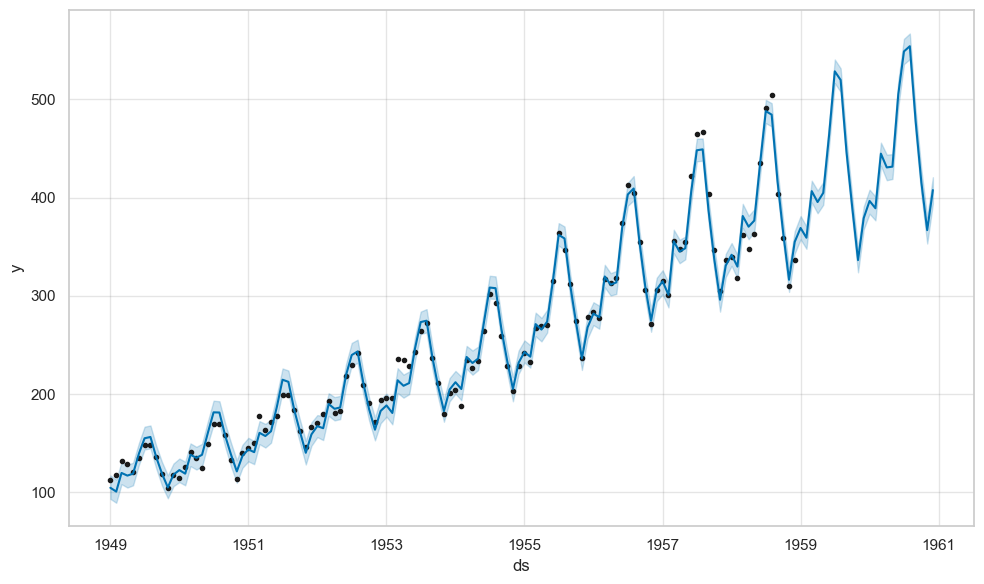

In [108]:
m.plot(forecast);

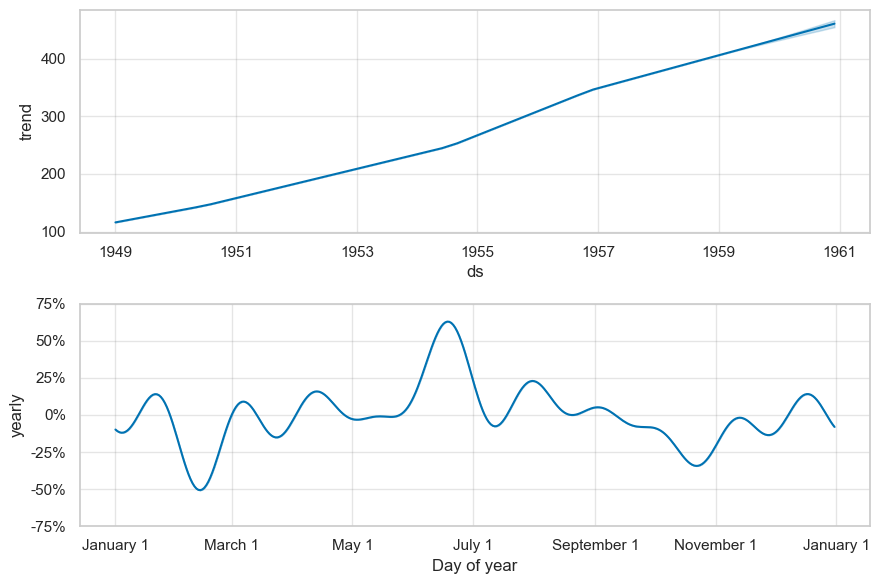

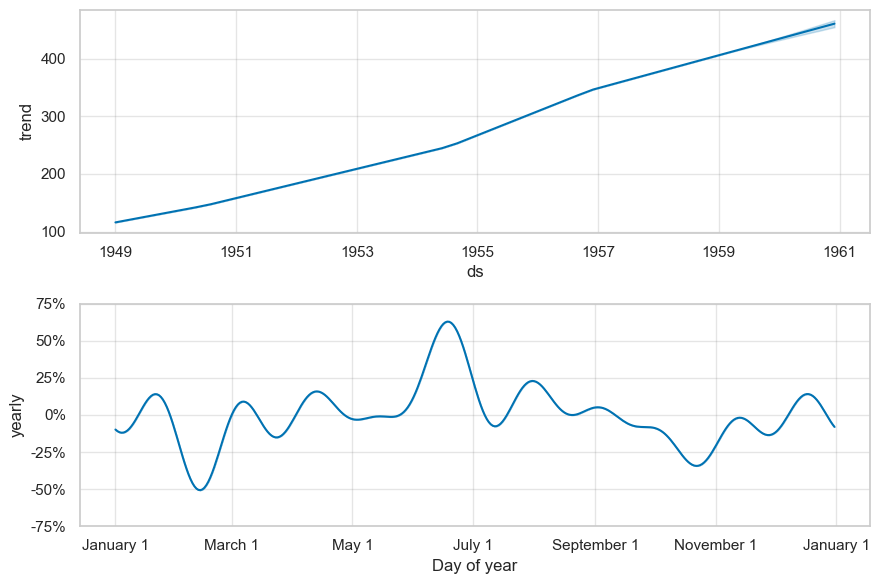

In [107]:
m.plot_components(forecast)

In [109]:
data = df.values.reshape(-1,1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [118]:
# create supervised dataset with lag=12 (use last 24 months as test)
lag = 36
X, y = [], []
for i in range(len(data_scaled)-lag):
    X.append(data_scaled[i:i+lag, 0])
    y.append(data_scaled[i+lag, 0])
X = np.array(X)
y = np.array(y)
# reshape for LSTM: [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

In [119]:
X[0]

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853],
       [0.05984556],
       [0.08494208],
       [0.08494208],
       [0.06177606],
       [0.02895753],
       [0.        ],
       [0.02702703],
       [0.02123552],
       [0.04247104],
       [0.07142857],
       [0.05984556],
       [0.04054054],
       [0.08687259],
       [0.12741313],
       [0.12741313],
       [0.1042471 ],
       [0.05598456],
       [0.01930502],
       [0.06949807],
       [0.07915058],
       [0.08880309],
       [0.14285714],
       [0.11389961],
       [0.13127413],
       [0.14285714],
       [0.18339768],
       [0.18339768],
       [0.15444015],
       [0.11196911],
       [0.08108108],
       [0.11969112]])

In [114]:
y[0]

0.02123552123552122

In [120]:
# train/test split corresponding to earlier split of last 24 months
train_X = X[:-test_periods]
train_y = y[:-test_periods]
test_X = X[-test_periods:]
test_y = y[-test_periods:]

print("LSTM shapes:", train_X.shape, train_y.shape, test_X.shape, test_y.shape)

# Build multi-layer LSTM
model = Sequential()
model.add(LSTM(100, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))
model.add(LSTM(50, activation='tanh', return_sequences=True))
model.add(LSTM(25, activation='tanh'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Model summary
model.summary()

LSTM shapes: (84, 36, 1) (84,) (24, 36, 1) (24,)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 36, 100)             │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 36, 50)              │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 25)                  │           7,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 78,871 (308.09 KB)

 Trainable params: 78,871 (308.09 KB)

 Non-trainable params: 0 (0.00 B)

In [121]:
# Train (small epochs for demo; increase for production)
history = model.fit(train_X, train_y, epochs=50, batch_size=16, validation_data=(test_X, test_y), verbose=1)

# Forecast - one-step predictions for test set
preds = model.predict(test_X)
preds_inv = scaler.inverse_transform(preds)  # back to original scale
test_y_inv = scaler.inverse_transform(test_y.reshape(-1,1))
# create pandas series for plotting aligned to test index
lstm_pred_series = pd.Series(preds_inv.flatten(), index=test.index)
lstm_true_series = pd.Series(test_y_inv.flatten(), index=test.index)
print("LSTM RMSE:", sqrt(mean_squared_error(lstm_true_series, lstm_pred_series)))

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - loss: 0.0695 - val_loss: 0.0451
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0197 - val_loss: 0.0658
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0168 - val_loss: 0.0263
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0122 - val_loss: 0.0197
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0119 - val_loss: 0.0346
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0117 - val_loss: 0.0279
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0086 - val_loss: 0.0202
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0090 - val_loss: 0.0296
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0098 - val_loss: 0.0196
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0099 - val_loss: 0.0235
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0085 - val_loss: 0.0255
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0104 - val_loss: 0.0205


<Figure size 2000x500 with 0 Axes>

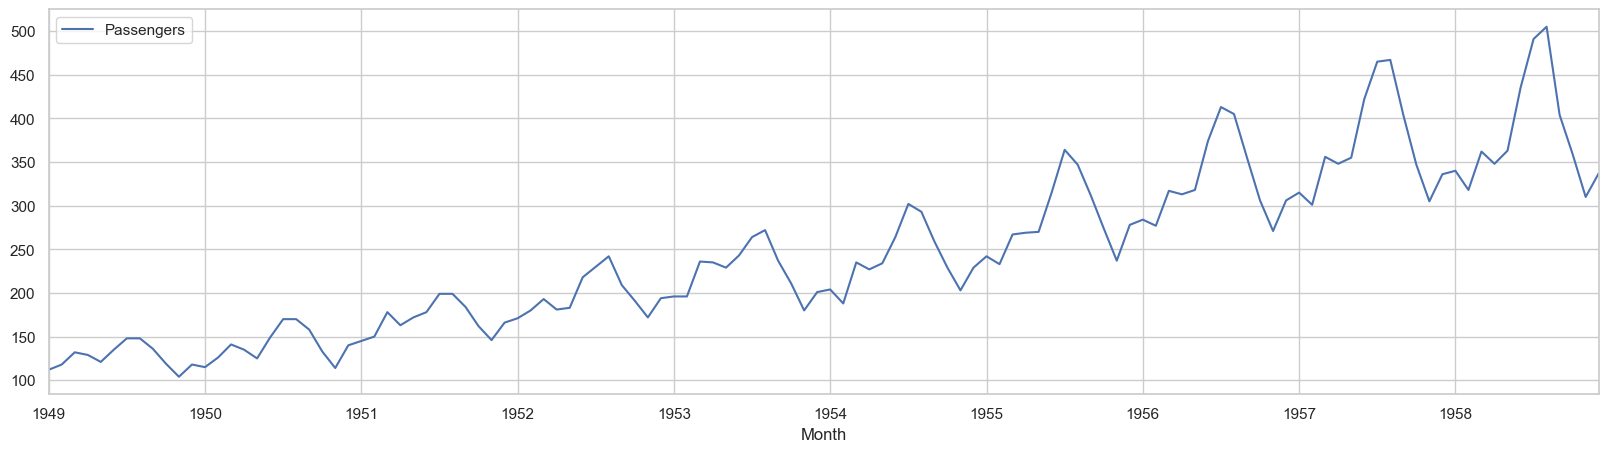

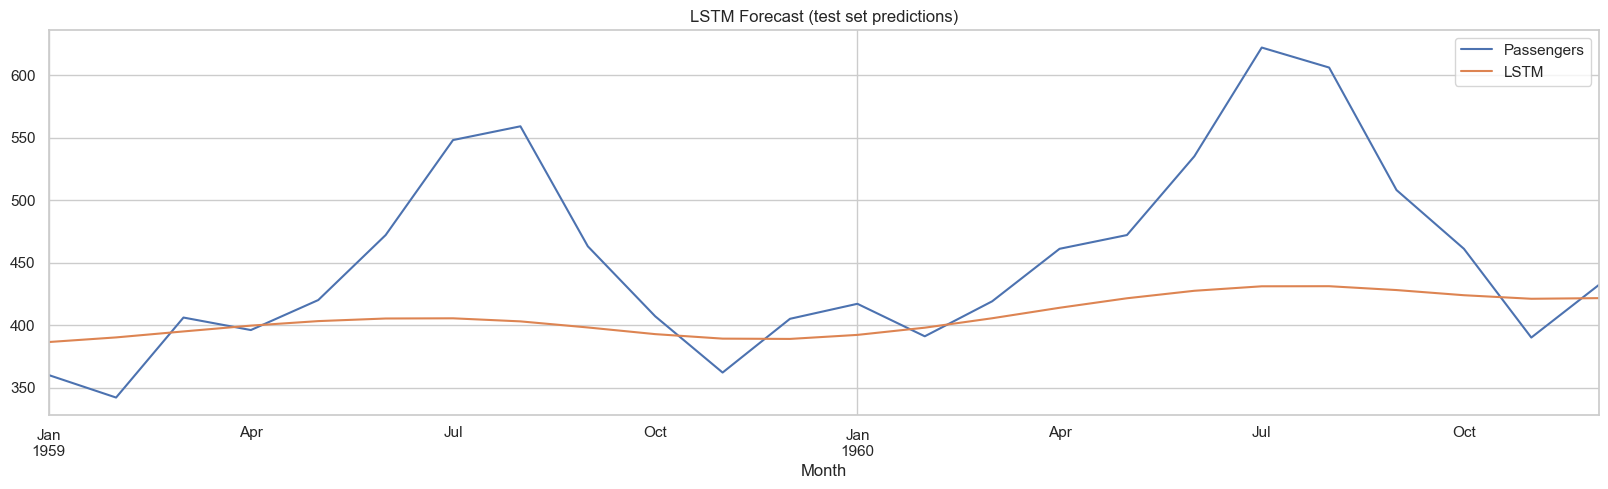

In [122]:
plt.figure()
train.plot(label='train')
test.plot(label='test')
lstm_pred_series.plot(label='LSTM')
plt.legend(); plt.title('LSTM Forecast (test set predictions)')
plt.show()